## 📄 README




**Animal Classification & Duplicate Detection**

---

**Objective**

The goal of this assignment was to build a simple image pipeline that can classify animals (cow vs buffalo) and detect near-duplicate images.

---

**1. Image Classification**

I used a pretrained ResNet18 model and applied transfer learning.

Since the dataset is very small (around 30 images), training a model from scratch would lead to overfitting. A pretrained model already understands general visual features like edges and textures, so it works much better for this task.

To keep training stable:

* most of the model was frozen
* only the final classification layer was trained

---

**Data Processing**

* images resized to 224 × 224
* applied basic augmentation:

  * horizontal flip
  * small rotations
  * brightness and contrast changes
* normalized using ImageNet statistics

---

**Handling Class Imbalance**

There were fewer buffalo images compared to cows, so I used a class-weighted loss function to reduce bias toward the cow class.

---

**Results**

* Accuracy: ~0.86
* F1 Score: ~0.86

From the confusion matrix:

* all cow images were classified correctly
* one buffalo image was misclassified as cow

Given the dataset size, this is a reasonable outcome.

---

**Observations / Failure Cases**

* dataset is small and slightly imbalanced
* cows and buffalo look similar under certain lighting conditions
* some images are blurry, which affects confidence

---

**2. Near-Duplicate Detection**

Duplicate detection was done using deep feature embeddings.

---

**Approach**

* extracted features from the second last layer of ResNet18
* generated embeddings for each image
* computed cosine similarity between all image pairs
* grouped images based on similarity threshold

---

**Threshold Selection**

A threshold of 0.92 was selected after inspecting the most similar image pairs.

* above 0.92 → near-duplicate or very similar
* below 0.90 → mostly different images

---

**Output Format**

Final output is saved as:

results.csv

with columns:

image_name, predicted_label, confidence_score, duplicate_group_id

Example:

img1.jpg → cow → 0.91 → group_0
img2.jpg → cow → 0.88 → group_0
img3.jpg → buffalo → 0.85 → None

---

**Scaling Considerations**

To scale this system for large datasets:

* run batch inference on GPU
* store embeddings in a vector database (like FAISS)
* use approximate nearest neighbor search
* process images in parallel
* cache embeddings to avoid recomputation

---

**Improvements**

With more time, I would:

* collect more balanced data
* fine-tune more layers of the model
* try better architectures like EfficientNet or CLIP
* use clustering algorithms for duplicate grouping

---

**Final Thoughts**

This pipeline works end-to-end:

* performs classification with reasonable accuracy
* detects similar images using embeddings
* produces structured output

The main limitation is dataset size, but the overall approach is scalable and practical.

---

**Setup**

pip install torch torchvision pandas scikit-learn matplotlib seaborn

---




In [7]:
!pip install -q torch torchvision scikit-learn pandas pillow matplotlib

In [10]:
DATASET_DIR = "/content/ML-assignment-dataset-20260414T062514Z-3-001.zip"
BATCH_SIZE = 16
IMG_SIZE = 224
NUM_EPOCHS = 5
LR = 1e-3

In [11]:
!pip install torch torchvision

Define transforms and dataset

In [12]:
from torchvision import datasets, transforms

In [14]:
import os
os.listdir("/content")

['.config', 'ML-assignment-dataset-20260414T121204Z-3-001.zip', 'sample_data']

In [16]:
import zipfile

zip_path = "/content/ML-assignment-dataset-20260414T121204Z-3-001.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [17]:
import os

dataset_dir = "/content/ML-assignment-dataset"

for item in os.listdir(dataset_dir):
    path = os.path.join(dataset_dir, item)
    print(item, "->", "folder" if os.path.isdir(path) else "file")

15512685761_1771308671961_17bca41f-fd76-4d08-8f51-e3f2b352d88f______udder.webp -> file
15512581266_1770114886448_originalFileName.webp -> file
15511800946_1771850598614_originalFileName.jpeg -> file
15501646269_1771849287414_c0900904-90d9-4075-b3cf-d66f3836f889______udder.jpeg -> file
15506362876_1771298905770_originalFileName.webp -> file
15512343148_1771852162468_originalFileName.jpeg -> file
Animal Mela Image.jpeg -> file
15509985498_1771851149749_originalFileName.jpeg -> file
Animal Mela IMG 2427.jpeg -> file
15509131078_1771741765017_originalFileName.webp -> file
1689343207809_IMG20230714133920.jpg -> file
1771852256726_image.jpg -> file
15509019228_1771819579987_originalFileName.webp -> file
15503005739_1771850130079_originalFileName.jpeg -> file
15508899541_1771706615639_originalFileName.webp -> file
15506056344_1771304609663_originalFileName.webp -> file
7014211591_1771852685634_originalFileName.jpeg -> file
data-PM.png -> file
Original File from .webp -> file
Animal Mela Image

In [18]:
import os

dataset_dir = "/content/ML-assignment-dataset"
for cls in ["cow", "buffalo"]:
    os.makedirs(os.path.join(dataset_dir, cls), exist_ok=True)

print(os.listdir(dataset_dir))

['15512685761_1771308671961_17bca41f-fd76-4d08-8f51-e3f2b352d88f______udder.webp', '15512581266_1770114886448_originalFileName.webp', '15511800946_1771850598614_originalFileName.jpeg', '15501646269_1771849287414_c0900904-90d9-4075-b3cf-d66f3836f889______udder.jpeg', '15506362876_1771298905770_originalFileName.webp', '15512343148_1771852162468_originalFileName.jpeg', 'Animal Mela Image.jpeg', '15509985498_1771851149749_originalFileName.jpeg', 'Animal Mela IMG 2427.jpeg', '15509131078_1771741765017_originalFileName.webp', '1689343207809_IMG20230714133920.jpg', '1771852256726_image.jpg', '15509019228_1771819579987_originalFileName.webp', '15503005739_1771850130079_originalFileName.jpeg', '15508899541_1771706615639_originalFileName.webp', '15506056344_1771304609663_originalFileName.webp', '7014211591_1771852685634_originalFileName.jpeg', 'data-PM.png', 'Original File from .webp', 'Animal Mela Image 2.jpeg', '15503458995_1771852087958_originalFileName.jpeg', 'Original File from PrimeTrade.w

In [19]:
import os
import shutil

dataset_dir = "/content/ML-assignment-dataset"
cow_dir = os.path.join(dataset_dir, "cow")

for file in os.listdir(dataset_dir):
    file_path = os.path.join(dataset_dir, file)

    if os.path.isfile(file_path):
        shutil.move(file_path, os.path.join(cow_dir, file))

print("Moved all files to cow folder")

Moved all files to cow folder


In [20]:
for cls in ["cow", "buffalo"]:
    path = os.path.join(dataset_dir, cls)
    print(cls, "->", len(os.listdir(path)))

cow -> 34
buffalo -> 0


Handling imbalanced dataset

In [21]:
import shutil

shutil.rmtree("/content/ML-assignment-dataset/buffalo")

In [22]:
from torchvision import datasets

dataset = datasets.ImageFolder("/content/ML-assignment-dataset")
print(dataset.classes)

['cow']


In [23]:
buffalo_files = [
    "15503005739_1771850130079_originalFileName.jpeg",
    "15503458995_1771852087958_originalFileName.jpeg",
    "15507430553_1771852152649_originalFileName.jpeg",
    "15507977491_1771851265520_originalFileName.jpeg",
    "15512343148_1771852162468_originalFileName.jpeg",
    "1771852256726_image.jpg",
]

In [26]:
import os
import shutil

dataset_dir = "/content/ML-assignment-dataset"

for file in buffalo_files:
    src = os.path.join(dataset_dir, "cow", file)  # currently all in cow
    dst = os.path.join(dataset_dir, "buffalo", file)

    if os.path.exists(src):
        shutil.move(src, dst)

print("Moved buffalo images")

Moved buffalo images


In [27]:
for cls in ["cow", "buffalo"]:
    path = os.path.join(dataset_dir, cls)
    print(cls, "->", len(os.listdir(path)))

cow -> 28
buffalo -> 6


In [28]:
import shutil

shutil.rmtree("/content/ML-assignment-dataset/.ipynb_checkpoints", ignore_errors=True)

In [29]:
from torchvision import datasets

dataset = datasets.ImageFolder("/content/ML-assignment-dataset")
print(dataset.classes)

['buffalo', 'cow']


Load the dataset with transforms

In [30]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [31]:
DATASET_DIR = "/content/ML-assignment-dataset"
full_dataset = datasets.ImageFolder(DATASET_DIR)
print(full_dataset.classes)
print(len(full_dataset))

['buffalo', 'cow']
34


Split train and validation

In [33]:
import torch
from torch.utils.data import DataLoader, random_split

SEED = 42
BATCH_SIZE = 8

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_dataset.dataset = datasets.ImageFolder(DATASET_DIR, transform=train_transform)
val_dataset.dataset = datasets.ImageFolder(DATASET_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Build the model

In [34]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = full_dataset.classes

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze backbone for small dataset
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, len(class_names))
)

model = model.to(device)

# class order: ['buffalo', 'cow']
weights = torch.tensor([1.0/6, 1.0/28], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Only train final layer
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

print(device)
print(class_names)
print("Class weights:", weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 41.1MB/s]


cpu
['buffalo', 'cow']
Class weights: tensor([0.1667, 0.0357])


Train the data


In [35]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds

In [36]:
NUM_EPOCHS = 8
best_val_acc = 0.0
best_model_path = "/content/best_model.pth"

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, all_labels, all_preds = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print("Best val acc:", best_val_acc)

Epoch 1/8
Train Loss: 0.8906 | Train Acc: 0.4815
Val Loss:   0.5720 | Val Acc:   0.7143
----------------------------------------
Epoch 2/8
Train Loss: 0.7034 | Train Acc: 0.7778
Val Loss:   0.7265 | Val Acc:   0.8571
----------------------------------------
Epoch 3/8
Train Loss: 0.9029 | Train Acc: 0.8148
Val Loss:   0.6102 | Val Acc:   0.8571
----------------------------------------
Epoch 4/8
Train Loss: 0.6327 | Train Acc: 0.8148
Val Loss:   0.5754 | Val Acc:   0.8571
----------------------------------------
Epoch 5/8
Train Loss: 0.4711 | Train Acc: 0.8889
Val Loss:   0.6263 | Val Acc:   0.8571
----------------------------------------
Epoch 6/8
Train Loss: 0.6602 | Train Acc: 0.8148
Val Loss:   0.6346 | Val Acc:   0.8571
----------------------------------------
Epoch 7/8
Train Loss: 0.5168 | Train Acc: 0.8519
Val Loss:   0.6709 | Val Acc:   0.8571
----------------------------------------
Epoch 8/8
Train Loss: 0.5407 | Train Acc: 0.9259
Val Loss:   0.6378 | Val Acc:   0.8571
---------

Get classification metrics

In [37]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

model.load_state_dict(torch.load(best_model_path, map_location=device))

val_loss, val_acc, all_labels, all_preds = evaluate(model, val_loader, criterion)

print(classification_report(all_labels, all_preds, target_names=class_names))
print("Precision:", precision_score(all_labels, all_preds, average="weighted"))
print("Recall:", recall_score(all_labels, all_preds, average="weighted"))
print("F1 Score:", f1_score(all_labels, all_preds, average="weighted"))

              precision    recall  f1-score   support

     buffalo       1.00      0.50      0.67         2
         cow       0.83      1.00      0.91         5

    accuracy                           0.86         7
   macro avg       0.92      0.75      0.79         7
weighted avg       0.88      0.86      0.84         7

Precision: 0.880952380952381
Recall: 0.8571428571428571
F1 Score: 0.8398268398268397


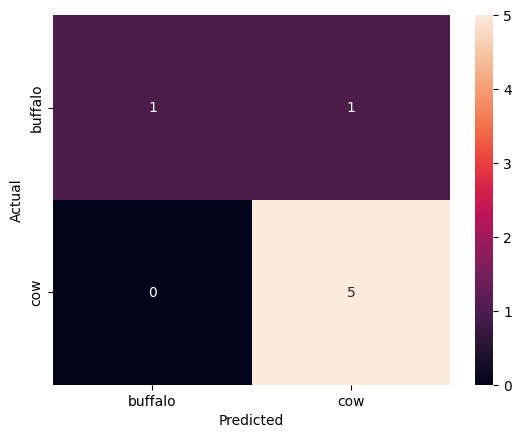

              precision    recall  f1-score   support

     buffalo       1.00      0.50      0.67         2
         cow       0.83      1.00      0.91         5

    accuracy                           0.86         7
   macro avg       0.92      0.75      0.79         7
weighted avg       0.88      0.86      0.84         7



In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

Run prediction on all images with confidence

In [39]:
import os
import pandas as pd
import torch.nn.functional as F

infer_dataset = datasets.ImageFolder(DATASET_DIR, transform=val_transform)
infer_loader = DataLoader(infer_dataset, batch_size=1, shuffle=False)

idx_to_class = {v: k for k, v in infer_dataset.class_to_idx.items()}

prediction_rows = []

model.eval()
with torch.no_grad():
    for i, (image, _) in enumerate(infer_loader):
        image = image.to(device)

        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, dim=1)

        img_path, _ = infer_dataset.samples[i]

        prediction_rows.append({
            "image_name": os.path.basename(img_path),
            "predicted_label": idx_to_class[pred.item()],
            "confidence_score": round(conf.item(), 4),
            "image_path": img_path
        })

pred_df = pd.DataFrame(prediction_rows)
pred_df.head()

,image_name,predicted_label,confidence_score,image_path
0,15503005739_1771850130079_originalFileName.jpeg,cow,0.8203,/content/ML-assignment-dataset/buffalo/1550300...
1,15503458995_1771852087958_originalFileName.jpeg,cow,0.6963,/content/ML-assignment-dataset/buffalo/1550345...
2,15507430553_1771852152649_originalFileName.jpeg,cow,0.7415,/content/ML-assignment-dataset/buffalo/1550743...
3,15507977491_1771851265520_originalFileName.jpeg,cow,0.7821,/content/ML-assignment-dataset/buffalo/1550797...
4,15512343148_1771852162468_originalFileName.jpeg,cow,0.6999,/content/ML-assignment-dataset/buffalo/1551234...


Do near-duplicate detection

In [40]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

feature_extractor = nn.Sequential(*list(model.children())[:-1]).to(device)
feature_extractor.eval()

embeddings = []
image_paths = []

with torch.no_grad():
    for i, (image, _) in enumerate(infer_loader):
        image = image.to(device)
        feat = feature_extractor(image)
        feat = feat.squeeze().cpu().numpy().flatten()

        embeddings.append(feat)
        image_paths.append(infer_dataset.samples[i][0])

embeddings = np.array(embeddings)
similarity_matrix = cosine_similarity(embeddings)

print(embeddings.shape)

(34, 512)


Group duplicates

In [41]:
threshold = 0.92

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx != ry:
            self.parent[ry] = rx

uf = UnionFind(len(image_paths))

for i in range(len(image_paths)):
    for j in range(i + 1, len(image_paths)):
        if similarity_matrix[i, j] >= threshold:
            uf.union(i, j)

root_to_group = {}
group_counter = 0
duplicate_group_ids = []

for i in range(len(image_paths)):
    root = uf.find(i)
    if root not in root_to_group:
        members = [k for k in range(len(image_paths)) if uf.find(k) == root]
        if len(members) == 1:
            root_to_group[root] = None
        else:
            root_to_group[root] = f"group_{group_counter}"
            group_counter += 1
    duplicate_group_ids.append(root_to_group[root])

pred_df["duplicate_group_id"] = duplicate_group_ids
pred_df.head()

,image_name,predicted_label,confidence_score,image_path,duplicate_group_id
0,15503005739_1771850130079_originalFileName.jpeg,cow,0.8203,/content/ML-assignment-dataset/buffalo/1550300...,None
1,15503458995_1771852087958_originalFileName.jpeg,cow,0.6963,/content/ML-assignment-dataset/buffalo/1550345...,None
2,15507430553_1771852152649_originalFileName.jpeg,cow,0.7415,/content/ML-assignment-dataset/buffalo/1550743...,None
3,15507977491_1771851265520_originalFileName.jpeg,cow,0.7821,/content/ML-assignment-dataset/buffalo/1550797...,group_0
4,15512343148_1771852162468_originalFileName.jpeg,cow,0.6999,/content/ML-assignment-dataset/buffalo/1551234...,None


Save final CSV

In [42]:
final_df = pred_df[["image_name", "predicted_label", "confidence_score", "duplicate_group_id"]]
final_df.to_csv("/content/results.csv", index=False)
final_df.head(20)

,image_name,predicted_label,confidence_score,duplicate_group_id
0,15503005739_1771850130079_originalFileName.jpeg,cow,0.8203,None
1,15503458995_1771852087958_originalFileName.jpeg,cow,0.6963,None
2,15507430553_1771852152649_originalFileName.jpeg,cow,0.7415,None
3,15507977491_1771851265520_originalFileName.jpeg,cow,0.7821,group_0
4,15512343148_1771852162468_originalFileName.jpeg,cow,0.6999,None
5,1771852256726_image.jpg,buffalo,0.6437,None
6,15501054283_1769930885365_originalFileName.webp,cow,0.7993,None
7,15501646269_1771849287414_c0900904-90d9-4075-b...,cow,0.7871,None
8,15506056344_1771304609663_originalFileName.webp,cow,0.8855,None
9,15506178363_1771396347247_originalFileName.webp,cow,0.9372,None


Inspect likely duplicate pairs

In [43]:
pairs = []
for i in range(len(image_paths)):
    for j in range(i + 1, len(image_paths)):
        if similarity_matrix[i, j] >= threshold:
            pairs.append((
                os.path.basename(image_paths[i]),
                os.path.basename(image_paths[j]),
                similarity_matrix[i, j]
            ))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
pd.DataFrame(pairs, columns=["image_1", "image_2", "similarity"]).head(20)

,image_1,image_2,similarity
0,15507977491_1771851265520_originalFileName.jpeg,2026-02-23 at 9.29.47 PM.png,0.926457


Download results

In [50]:
final_df["duplicate_group_id"] = final_df["duplicate_group_id"].fillna("None")

/tmp/ipykernel_6067/2729975238.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["duplicate_group_id"] = final_df["duplicate_group_id"].fillna("None")


In [54]:
import pandas as pd

df = pd.read_csv("/content/results.csv", keep_default_na=False)
print(df.head())

                                        image_name predicted_label  \
0  15503005739_1771850130079_originalFileName.jpeg             cow   
1  15503458995_1771852087958_originalFileName.jpeg             cow   
2  15507430553_1771852152649_originalFileName.jpeg             cow   
3  15507977491_1771851265520_originalFileName.jpeg             cow   
4  15512343148_1771852162468_originalFileName.jpeg             cow   

   confidence_score duplicate_group_id  
0            0.8203               None  
1            0.6963               None  
2            0.7415               None  
3            0.7821            group_0  
4            0.6999               None  


In [55]:
final_df = final_df.copy()
final_df.loc[:, "duplicate_group_id"] = final_df["duplicate_group_id"].fillna("no_duplicate")
final_df.to_csv("/content/results.csv", index=False)

df = pd.read_csv("/content/results.csv", keep_default_na=False)
print(df.head())

                                        image_name predicted_label  \
0  15503005739_1771850130079_originalFileName.jpeg             cow   
1  15503458995_1771852087958_originalFileName.jpeg             cow   
2  15507430553_1771852152649_originalFileName.jpeg             cow   
3  15507977491_1771851265520_originalFileName.jpeg             cow   
4  15512343148_1771852162468_originalFileName.jpeg             cow   

   confidence_score duplicate_group_id  
0            0.8203               None  
1            0.6963               None  
2            0.7415               None  
3            0.7821            group_0  
4            0.6999               None  


In [56]:
from google.colab import files
files.download("/content/results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
final_df.to_csv("results.csv", index=False)